# Frankenstein vs. SFA RESI (long branch), per orbit

Compares CQSFA's Coulomb-corrected orbit trajectories ("Frankenstein") against OrbitFinder's own
Coulomb-free SFA RESI reference, for orbit 1 and orbit 2 in turn.

Both distributions reuse OrbitFinder's validated uniform approximation (`getMij_C`/`getMij_Q`)
for electron 1's own short+long branches - unchanged, since `CQSFA_fwd`'s C++ source has no
uniform-approximation/Stokes-transition treatment at all (confirmed: no Bessel/Stokes code in
`CQSFA_fwd/src`, only in `OrbitFinder/ActionAnalytics.cpp`).

Electron 2 differs between the two distributions:
- **Frankenstein**: only CQSFA's Coulomb-corrected orbit time is used (single branch, no
  second electron-2 path to interfere with), weighted by CQSFA's native `qPref` (stability-factor
  prefactor).
- **SFA RESI**: standard, Coulomb-free, no CQSFA correction. OrbitFinder's own field-only time
  has both a short and a long branch (`T3S`, `T3L`), but naively summing `M(T3S)+M(T3L)`
  reproduces the exact same near-Stokes-transition artifact (vertical striping) that
  `getMij_C`/`getMij_Q` fixes for electron 1 - electron 2's pair would need its own (simpler,
  single-time) uniform approximation to combine properly, which isn't implemented yet. Until
  then, only the **long** branch is used, matching the native OrbitFinder reference's own
  convention. The native-vs-Python-recompute cross-check further down is a light sanity check of
  this SFA RESI pipeline itself (independent of CQSFA/orbit choice), not a claim of full physical
  correctness for the naive short+long combination.


In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
import time

ATTOPYTHON_ROOT = "/workspaces/CQSFA/AttoPython"
if ATTOPYTHON_ROOT not in sys.path:
    sys.path.insert(0, ATTOPYTHON_ROOT)

import importlib
import Source.CQSFA
importlib.reload(Source.CQSFA)  # kernel may already have an older cached copy of this module
from Source.CQSFA import RESIParams, load_orbit, compute_electron1_times, compute_M, compute_M_native

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit1only_better"
GRID_TAG = "141X141"  # OrbitFinder's own p_long x p_trans grid
RUN_TAG = "orbit1only_better"  # source-restricted (100%-pure) orbit-1-only build, validated in Per_Orbit_Amplitude.ipynb
NINITCOND_TAG = "100000"

omega = 0.057
Up = 0.6579
Up0 = Up / omega

Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)
BUMP = 1e-4
params = RESIParams(omega=omega, Up0=Up0, Ip1=Ip1, Ip2=Ip2, Ip12=Ip12, BUMP=BUMP)


## Validated building blocks

Now live in `Source/CQSFA.py` (`f12`/`f3`/`hessian_f12`/`d33_f3`/`getA`/`getMij_C`/`getMij_Q`/
`load_orbit`/`compute_electron1_times`/`compute_M`), imported above, so other notebooks
(`Per_Orbit_Amplitude.ipynb`, etc.) can reuse the same validated implementation.


## Electron 1 and electron 2's SFA times: OrbitFinder's own short/long branches (unchanged, native grid)

In [2]:
pax, tax, T1S, T2S, T3S = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.shortorbit")
_, _, T1L, T2L, T3L = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.longorbit")
n = len(pax)
hsize = int(np.floor(n / 2.0 + 0.5))  # C++ std::round (round-half-away-from-zero)
tax_half = pax[:hsize]
print(f"grid {n}x{n}, hsize={hsize}, p_trans (half) in [{tax_half.min():.3f},{tax_half.max():.3f}]")


grid 141x141, hsize=71, p_trans (half) in [-4.315,0.000]


## Electron 1's own short/long quantities (independent of electron 2's time), computed once

In [3]:
e1_times = compute_electron1_times(params, pax, tax_half, T1S, T2S, T1L, T2L)

p1trans_w = tax_half[None, None, :, None]
p2trans_w = tax_half[None, None, None, :]


## Electron 2, Frankenstein branch: CQSFA's Coulomb-corrected orbit-1 time only

Interpolated from the `orbit1only` run's `Binned_Initial_Condition_Grid` (the genuinely
orbit-1-only `Amplitude.cpp` build validated in `Per_Orbit_Amplitude.ipynb`), filtered to
`orbit==1`, onto OrbitFinder's own `(pax, tax_half)` grid.

In [4]:
cqsfa_data = np.loadtxt(f"{CQSFA_dir}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
orbit_raw = cqsfa_data[:, 9].astype(int)
pf_z, pf_perp = cqsfa_data[:, 6], cqsfa_data[:, 7]
t0_raw = omega * (cqsfa_data[:, 3] + 1j * cqsfa_data[:, 4])  # phase-convert absolute time -> omega*t

# Prefactor_Grid rows are in the exact same order as Binned_Initial_Condition_Grid's (both just
# filter the same underlying g1 array by usePointQ, in the same order - see Prefactors::printToFile
# / initCondsGrid::printToFile), so the same row mask applies to both files directly.
prefactor_data = np.loadtxt(f"{CQSFA_dir}/Data/Prefactor_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
qpref_raw = prefactor_data[:, 6] + 1j * prefactor_data[:, 7]       # CQSFA_fwd's own native qPref (stability factor only)

mask1 = orbit_raw == 1
print(f"orbit 1: {mask1.sum()} points, pf_z in [{pf_z[mask1].min():.2f},{pf_z[mask1].max():.2f}], "
      f"pf_perp in [{pf_perp[mask1].min():.2f},{pf_perp[mask1].max():.2f}]")

P2L_full, P2T_full = np.meshgrid(pax, tax_half, indexing="ij")  # same shape as electron 1's own grid


def interp_complex(vals_re, vals_im, pf_z_src, pf_perp_src, mask):
    re_grid = griddata((pf_z_src[mask], pf_perp_src[mask]), vals_re[mask], (P2L_full, P2T_full), method="linear")
    im_grid = griddata((pf_z_src[mask], pf_perp_src[mask]), vals_im[mask], (P2L_full, P2T_full), method="linear")
    return re_grid + 1j * im_grid


T0_orbit1 = interp_complex(t0_raw.real, t0_raw.imag, pf_z, pf_perp, mask1)
valid_orbit1 = np.isfinite(T0_orbit1)
print(f"interpolated grid coverage (non-nan) = {valid_orbit1.mean():.2f}")

QPref_orbit1 = interp_complex(qpref_raw.real, qpref_raw.imag, pf_z, pf_perp, mask1)


orbit 1: 121292 points, pf_z in [-2.50,2.50], pf_perp in [-1.32,1.32]
interpolated grid coverage (non-nan) = 0.15


## Orbit 1: build Frankenstein (native qPref) and SFA RESI (standard, long branch) amplitudes

In [5]:
t_start = time.time()
M_frankenstein_qpref = compute_M_native(params, e1_times, T0_orbit1, QPref_orbit1, valid_orbit1)
prob_frankenstein_qpref = (np.abs(M_frankenstein_qpref) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))
del M_frankenstein_qpref
print("Frankenstein (orbit 1, native qPref) elapsed:", time.time() - t_start)

valid_all = np.ones((n, hsize), dtype=bool)
t_start = time.time()
M_sfa_long = compute_M(params, e1_times, T3L[:, :hsize], valid_all)
prob_sfa_resi = (np.abs(M_sfa_long) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))
del M_sfa_long
print("SFA RESI (long) elapsed:", time.time() - t_start)

# Electron 2's own short/long branches (T3S vs T3L) are a SEPARATE coalescing-saddle-point pair
# from electron 1's (already handled correctly inside compute_M via getMij_C/getMij_Q + Stokes
# selection). getMij_C/getMij_Q can't be reused for electron 2's pair as-is - they're derived for
# electron 1's bivariate (t1,t2) saddle problem, not electron 2's single-time one - and naively
# summing M_short+M_long reproduces exactly the "naive coherent summing near a Stokes transition"
# artifact that was fixed for electron 1 elsewhere in this notebook, visible as vertical
# comb/striping in the momentum map. Until a proper 1D uniform approximation for electron 2's own
# short/long pair is implemented, use ONLY the long branch, matching the native OrbitFinder
# reference's own convention (see the cross-check cell below).
# Each M_* array is ~1.6GB (141x141x71x71 complex128) - delete it immediately after reducing to
# the much smaller prob_* map, since keeping several alive at once is what caused the earlier
# out-of-memory kernel crash.

print(f"Frankenstein (orbit 1, native qPref) max      = {np.abs(prob_frankenstein_qpref).max():.3e}")
print(f"SFA RESI (long) max  = {np.abs(prob_sfa_resi).max():.3e}")


Frankenstein (orbit 1, native qPref) elapsed: 44.7580509185791
SFA RESI (long) elapsed: 116.87843799591064
Frankenstein (orbit 1, native qPref) max      = 3.604e-09
SFA RESI (long) max  = 4.530e-12


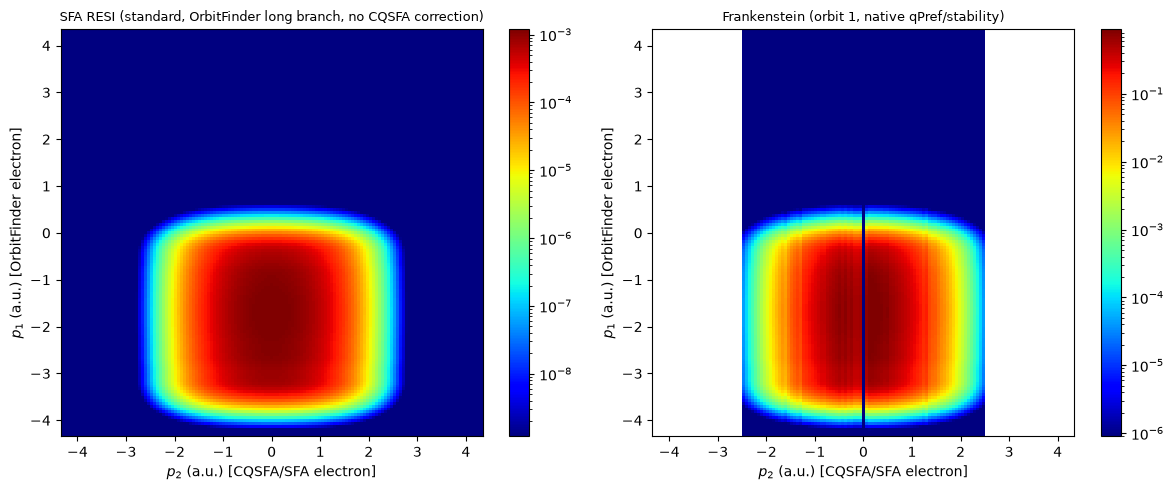

In [6]:
shared_norm = max(np.abs(prob_sfa_resi).max(), np.abs(prob_frankenstein_qpref).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d_raw, title in [
    (axes[0], prob_sfa_resi, "SFA RESI (standard, OrbitFinder long branch, no CQSFA correction)"),
    (axes[1], prob_frankenstein_qpref, "Frankenstein (orbit 1, native qPref/stability)"),
]:
    d = np.abs(d_raw) / shared_norm
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

## Cross-check: native OrbitFinder output (independent validation)

`AggregateChannels::SaveAmplitudes` + `IntegratePerp` (in `OrbitFinder/AggregateChannels.cpp`)
already compute this same uniform-approximation SFA amplitude for the `141X141` grid and write
the p_trans-integrated coherent probability map to `..._ChannelSum_0_Coh.L` (ASCII `i j value`).
Loading it here gives an independent check of the from-scratch Python recompute (`prob_sfa_resi`)
above, using the actual validated C++ implementation rather than a Python reimplementation.

Note: the native code always uses electron 2's **long** action value (short vs. long only
changes which time feeds the Hessian/prefactor) - it does not coherently sum two fully
independent electron-2 short/long amplitudes the way `M_sfa_short + M_sfa_long` does above. A
small systematic difference from that is therefore expected, not necessarily a bug.


native file: /workspaces/CQSFA/OrbitFinder/TestingSuite/results/helium_resi_cross_quadrant.inpPre_0_Range_141X141_Up_0_ChannelSum_0_Coh.L
native max = 4.528e-12, Python recompute max = 4.530e-12
correlation (native OrbitFinder vs. Python recompute) = 1.0000


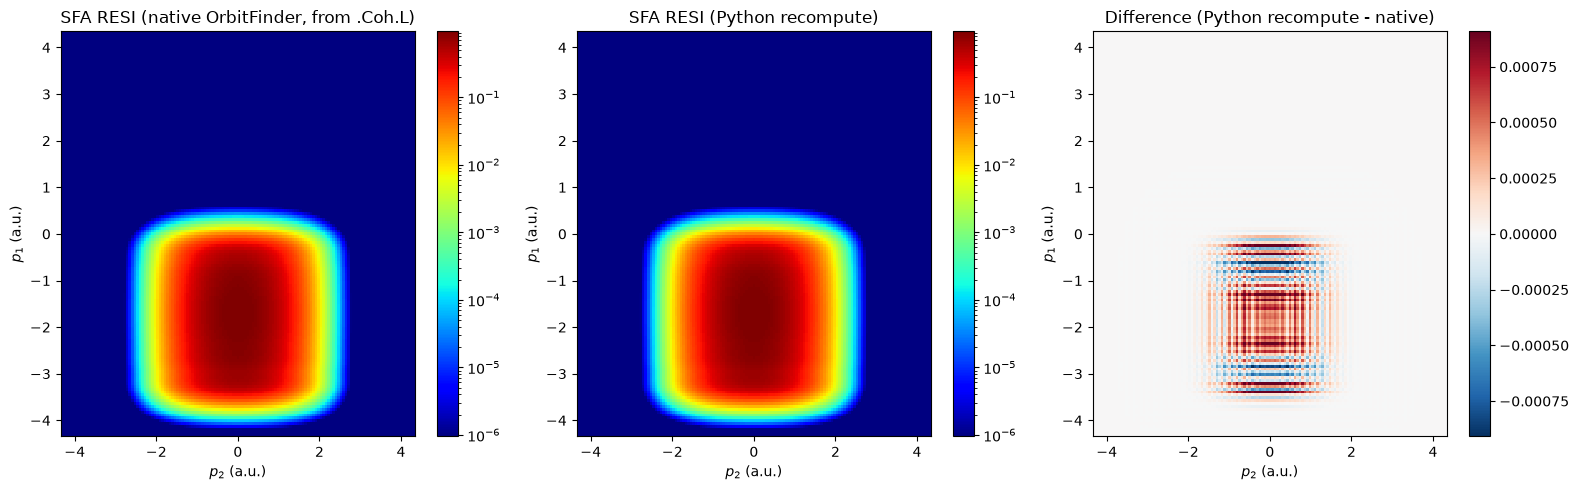

In [7]:
native_file = f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inpPre_0_Range_{GRID_TAG}_Up_0_ChannelSum_0_Coh.L"
native_raw = np.loadtxt(native_file)
i_native, j_native = native_raw[:, 0].astype(int), native_raw[:, 1].astype(int)
prob_sfa_native = np.zeros((n, n))
prob_sfa_native[i_native, j_native] = native_raw[:, 2]

corr = np.corrcoef(prob_sfa_native.ravel(), np.abs(prob_sfa_resi).ravel())[0, 1]
print(f"native file: {native_file}")
print(f"native max = {prob_sfa_native.max():.3e}, Python recompute max = {np.abs(prob_sfa_resi).max():.3e}")
print(f"correlation (native OrbitFinder vs. Python recompute) = {corr:.4f}")

shared_norm_native = max(prob_sfa_native.max(), np.abs(prob_sfa_resi).max())
d_native = prob_sfa_native / shared_norm_native
d_python = np.abs(prob_sfa_resi) / shared_norm_native

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [
    (axes[0], d_native, "SFA RESI (native OrbitFinder, from .Coh.L)"),
    (axes[1], d_python, "SFA RESI (Python recompute)"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.)"); ax.set_ylabel(r"$p_{1}$ (a.u.)")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

diff_native = d_python - d_native
vmax_dn = np.percentile(np.abs(diff_native), 99.5)
pcm3 = axes[2].pcolormesh(pax, pax, diff_native, vmin=-vmax_dn, vmax=vmax_dn, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{2}$ (a.u.)"); axes[2].set_ylabel(r"$p_{1}$ (a.u.)")
axes[2].set_title("Difference (Python recompute - native)")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.show()


## Electron 2, Frankenstein branch: orbit 2 (from the genuinely orbit-2-only run)

Same treatment as orbit 1, but interpolated from the `orbit2only` run's own
`Binned_Initial_Condition_Grid` (genuinely orbit-2-only `Amplitude.cpp` build), filtered to
`orbit==2`, onto OrbitFinder's own `(pax, tax_half)` grid.


In [8]:
CQSFA_dir_orbit2 = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit2only_better"
RUN_TAG_orbit2 = "orbit2only_better"

cqsfa_data_orbit2 = np.loadtxt(f"{CQSFA_dir_orbit2}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG_orbit2}_{NINITCOND_TAG}.dat")
orbit_raw2 = cqsfa_data_orbit2[:, 9].astype(int)
pf_z2, pf_perp2 = cqsfa_data_orbit2[:, 6], cqsfa_data_orbit2[:, 7]
t0_raw2 = omega * (cqsfa_data_orbit2[:, 3] + 1j * cqsfa_data_orbit2[:, 4])

prefactor_data_orbit2 = np.loadtxt(f"{CQSFA_dir_orbit2}/Data/Prefactor_Grid_Frankenstein_He_electron2_{RUN_TAG_orbit2}_{NINITCOND_TAG}.dat")
qpref_raw2 = prefactor_data_orbit2[:, 6] + 1j * prefactor_data_orbit2[:, 7]

mask2 = orbit_raw2 == 2
print(f"orbit 2: {mask2.sum()} points, pf_z in [{pf_z2[mask2].min():.2f},{pf_z2[mask2].max():.2f}], "
      f"pf_perp in [{pf_perp2[mask2].min():.2f},{pf_perp2[mask2].max():.2f}]")

T0_orbit2 = interp_complex(t0_raw2.real, t0_raw2.imag, pf_z2, pf_perp2, mask2)
valid_orbit2 = np.isfinite(T0_orbit2)

print(f"interpolated grid coverage (non-nan) = {valid_orbit2.mean():.2f}")

QPref_orbit2 = interp_complex(qpref_raw2.real, qpref_raw2.imag, pf_z2, pf_perp2, mask2)

orbit 2: 146592 points, pf_z in [-2.50,2.50], pf_perp in [-1.32,1.32]
interpolated grid coverage (non-nan) = 0.15


## Orbit 2: build Frankenstein (native qPref) amplitude, compare against SFA RESI

Reuses `prob_sfa_resi` (SFA RESI, long branch) already computed above - it doesn't depend on
which CQSFA orbit is being compared against, only on OrbitFinder's own field-only electron-2 time.

In [9]:
t_start = time.time()
M_frankenstein_orbit2_qpref = compute_M_native(params, e1_times, T0_orbit2, QPref_orbit2, valid_orbit2)
prob_frankenstein_orbit2_qpref = (np.abs(M_frankenstein_orbit2_qpref) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))
del M_frankenstein_orbit2_qpref
print("Frankenstein (orbit 2, native qPref) elapsed:", time.time() - t_start)

print(f"Frankenstein (orbit 2, native qPref) max      = {np.abs(prob_frankenstein_orbit2_qpref).max():.3e}")

Frankenstein (orbit 2, native qPref) elapsed: 44.463613748550415
Frankenstein (orbit 2, native qPref) max      = 5.191e-09


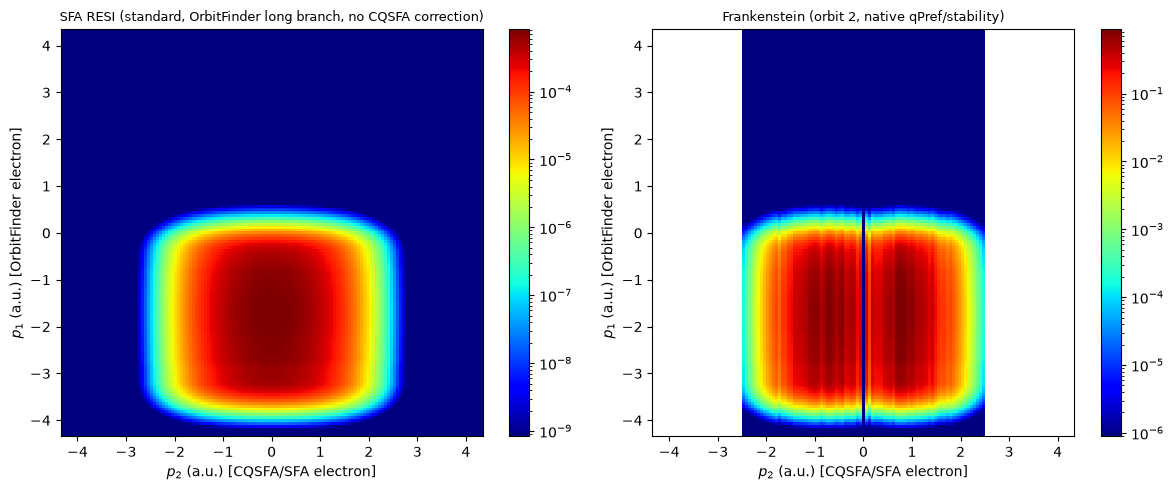

In [10]:
shared_norm_orbit2 = max(np.abs(prob_sfa_resi).max(), np.abs(prob_frankenstein_orbit2_qpref).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d_raw, title in [
    (axes[0], prob_sfa_resi, "SFA RESI (standard, OrbitFinder long branch, no CQSFA correction)"),
    (axes[1], prob_frankenstein_orbit2_qpref, "Frankenstein (orbit 2, native qPref/stability)"),
]:
    d = np.abs(d_raw) / shared_norm_orbit2
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()